# Multi-Model Feature Selector Notebook

Runs **LOCO**, **coalition SHAP**, and **FFS** for prior VLST models on the same records/split protocol as `tabpfn.ipynb`.

- Models: `lr`, `rf`, `rf_b`, `cat`, `xgb`, `xgb_b`, `lgb`, optional `tabpfn`
- Objectives: `pr_auc`, `f1`, `f2`
- Final outputs include:
  - all unique selected features across all models/algorithms/metrics
  - common features shared by all models per algorithm (and per metric)

In [1]:
import json
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# -------------------------------
# Runtime controls
# -------------------------------
RUN_MODE = "smoke"        # "smoke" or "full"
USE_CACHE = True
USE_GPU = True            # set False to force CPU for all GPU-capable models

RANDOM_STATE = 42
TEST_SIZE = 0.30
TARGET_COL = "Stent thrombosis"
DROP_FEATURES = ["Time since stent implantation"]
ID_COLS = ["NO.", "Name"]

SCORINGS = ["pr_auc", "f1", "f2"]
BETA_F2 = 2.0
THRESHOLD_GRID_POINTS = 199

PRIORITY_FEATURES = [
    "Age, years",
    "Male sex",
    "Current drinking",
    "Diabetes mellitus",
    "aspirin",
    "Hypertension",
    "Dapt",
    "Dyslipidemia",
    "HbA1C",
    "Clopidogrel",
    "Current smoker",
]

# GPU detection (Kaggle T4: enable GPU in notebook settings)
try:
    import torch

    CUDA_AVAILABLE = bool(USE_GPU and torch.cuda.is_available())
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"
TABPFN_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"

if RUN_MODE == "smoke":
    FEATURE_TOPK = 12
    SHAP_UNIVERSE = 24
    SHAP_N_PERM = 12
    SHAP_N_INSTANCES = 32
    SHAP_N_BACKGROUND = 32
    LOCO_MAX_FEATURES = 40
    FFS_CANDIDATE_POOL = 30
    SELECTOR_CAT_ITERS = 200
    SELECTOR_XGB_ROUNDS = 200
    SELECTOR_LGB_ROUNDS = 200
else:
    FEATURE_TOPK = 20
    SHAP_UNIVERSE = 40
    SHAP_N_PERM = 40
    SHAP_N_INSTANCES = 64
    SHAP_N_BACKGROUND = 64
    LOCO_MAX_FEATURES = 60          # keep capped — full 185-feature LOCO is extremely slow
    FFS_CANDIDATE_POOL = 50
    SELECTOR_CAT_ITERS = 400
    SELECTOR_XGB_ROUNDS = 400
    SELECTOR_LGB_ROUNDS = 400

print("RUN_MODE:", RUN_MODE)
print("GPU:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE, "| LGB:", LGB_DEVICE, "| TabPFN:", TABPFN_DEVICE)

RUN_MODE: smoke
GPU: True | Tesla T4
CatBoost: GPU | XGB: cuda | LGB: gpu | TabPFN: cuda


In [2]:
# -------------------------------
# Paths and data loaders (tabpfn.ipynb/results.ipynb protocol)
# -------------------------------
KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_OUT_DIR = "/kaggle/working/model_feature_selectors"


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above the current working directory.")


# Detect Kaggle vs local
IS_KAGGLE = Path("/kaggle/working").is_dir()
if IS_KAGGLE:
    RAW_PATH = Path(os.environ.get("VLST_RAW_CSV", KAGGLE_RAW_CSV))
    OUT_DIR = Path(os.environ.get("VLST_RESULT_DIR", KAGGLE_OUT_DIR))
else:
    REPO_ROOT = _find_repo_root()
    RAW_PATH = Path(os.environ.get("VLST_RAW_CSV", REPO_ROOT / "data" / "raw" / "VLST.csv"))
    OUT_DIR = Path(os.environ.get("VLST_RESULT_DIR", REPO_ROOT / "data" / "result" / "model_feature_selectors"))

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Runtime:", "Kaggle" if IS_KAGGLE else "local")
print("RAW_PATH:", RAW_PATH)
print("OUT_DIR:", OUT_DIR)


def load_raw_tabpfn_native(raw_path: Path):
    df = pd.read_csv(raw_path)
    df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
    y = df[TARGET_COL].astype(int).to_numpy()
    drop = [TARGET_COL] + [c for c in DROP_FEATURES if c in df.columns]
    x_df = df.drop(columns=drop)
    for c in x_df.columns:
        if x_df[c].dtype == object:
            coerced = pd.to_numeric(x_df[c].astype(str).str.strip(), errors="coerce")
            if coerced.notna().mean() >= 0.5:
                x_df[c] = coerced
            else:
                codes = x_df[c].astype("category").cat.codes.astype(float)
                x_df[c] = codes.where(codes >= 0, np.nan)
    return x_df.to_numpy(dtype=float), y, list(x_df.columns)


def load_dataframe_for_scaled(raw_path: Path):
    df = pd.read_csv(raw_path)
    df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
    df = df.drop(columns=[c for c in DROP_FEATURES if c in df.columns])
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").astype(int)
    return df


def _feature_columns(df):
    feature_cols = [c for c in df.columns if c != TARGET_COL]
    numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()
    binary_cols = [
        c for c in numeric_cols
        if set(df[c].dropna().unique()).issubset({0, 1}) and df[c].nunique(dropna=True) <= 2
    ]
    continuous_cols = [c for c in numeric_cols if c not in binary_cols]
    return feature_cols, binary_cols, continuous_cols, cat_cols


def df_to_scaled(df):
    feature_cols, binary_cols, continuous_cols, cat_cols = _feature_columns(df)
    transformers = []
    if continuous_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), continuous_cols))
    if binary_cols:
        transformers.append(("bin", SimpleImputer(strategy="most_frequent"), binary_cols))
    if cat_cols:
        ohe = OneHotEncoder(drop="first", handle_unknown="ignore")
        transformers.append(
            ("cat", Pipeline([
                ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                ("ohe", ohe),
            ]), cat_cols)
        )
    pre = ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)
    x_enc = pre.fit_transform(df[feature_cols].copy())
    names = pre.get_feature_names_out().tolist()
    scaler = StandardScaler()
    return scaler.fit_transform(x_enc).astype(np.float64), names


df = load_dataframe_for_scaled(RAW_PATH)
X_raw_all, y_all, raw_feature_names = load_raw_tabpfn_native(RAW_PATH)
X_scaled_all, scaled_feature_names = df_to_scaled(df)
assert np.array_equal(y_all, df[TARGET_COL].to_numpy())

print("Rows:", len(y_all), "| raw features:", len(raw_feature_names), "| scaled features:", len(scaled_feature_names))

Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
OUT_DIR: /kaggle/working/model_feature_selectors
Rows: 5185 | raw features: 81 | scaled features: 185


In [3]:
# -------------------------------
# Split (must match tabpfn.ipynb)
# -------------------------------
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(
    idx_all,
    test_size=TEST_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

X_raw_train, X_raw_test = X_raw_all[train_idx], X_raw_all[test_idx]
X_scaled_train, X_scaled_test = X_scaled_all[train_idx], X_scaled_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

split_manifest = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "n_total": int(len(y_all)),
    "n_train": int(len(train_idx)),
    "n_test": int(len(test_idx)),
    "train_pos": int((y_train == 1).sum()),
    "test_pos": int((y_test == 1).sum()),
    "raw_n_features": len(raw_feature_names),
    "scaled_n_features": len(scaled_feature_names),
}

(OUT_DIR / "split_manifest.json").write_text(json.dumps(split_manifest, indent=2), encoding="utf-8")

print(split_manifest)
print("Expected tabpfn-ish split: total=5185, train=3629, test=1556, test_pos=28")

if split_manifest["n_total"] != 5185 or split_manifest["n_train"] != 3629 or split_manifest["n_test"] != 1556:
    print("WARNING: current raw CSV differs from previous row counts.")

for leak_col in DROP_FEATURES:
    assert leak_col not in raw_feature_names, f"Leakage feature still present in raw view: {leak_col}"
    assert leak_col not in scaled_feature_names, f"Leakage feature still present in scaled view: {leak_col}"
print("Leakage-column check passed for raw and scaled feature names.")

{'random_state': 42, 'test_size': 0.3, 'n_total': 5185, 'n_train': 3629, 'n_test': 1556, 'train_pos': 64, 'test_pos': 28, 'raw_n_features': 81, 'scaled_n_features': 185}
Expected tabpfn-ish split: total=5185, train=3629, test=1556, test_pos=28
Leakage-column check passed for raw and scaled feature names.


In [4]:
# -------------------------------
# Models (results.ipynb scope: base + diversity)
# -------------------------------
class CatBoostClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.model_ = CatBoostClassifier(**kwargs)

    def get_params(self, deep=True):
        return dict(self.kwargs)

    def set_params(self, **params):
        self.kwargs.update(params)
        self.model_ = CatBoostClassifier(**self.kwargs)
        return self

    def fit(self, X, y, **fit_params):
        X = np.ascontiguousarray(X, dtype=np.float32)
        try:
            self.model_.fit(X, y, **fit_params)
        except Exception as exc:
            if self.kwargs.get("task_type") == "GPU":
                print("CatBoost GPU fit failed; retrying on CPU:", exc)
                self.kwargs = dict(self.kwargs)
                self.kwargs["task_type"] = "CPU"
                self.kwargs.pop("devices", None)
                self.model_ = CatBoostClassifier(**self.kwargs)
                self.model_.fit(X, y, **fit_params)
            else:
                raise
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        X = np.ascontiguousarray(X, dtype=np.float32)
        return self.model_.predict_proba(X)


SCALE_POS_WEIGHT = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))


def make_lr(seed=RANDOM_STATE):
    return LogisticRegression(C=2.0, solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=seed)


def make_rf(seed=RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=seed,
    )


def make_rf_b(seed=RANDOM_STATE):
    m = make_rf(seed=137 + seed)
    m.set_params(max_samples=0.88)
    return m


def make_cat(seed=RANDOM_STATE):
    kwargs = dict(
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5.0,
        iterations=SELECTOR_CAT_ITERS,
        loss_function="Logloss",
        eval_metric="AUC",
        logging_level="Silent",
        allow_writing_files=False,
        auto_class_weights="Balanced",
        random_seed=seed,
        thread_count=-1,
    )
    if CATBOOST_TASK_TYPE == "GPU":
        kwargs.update(task_type="GPU", devices="0")
    else:
        kwargs.update(task_type="CPU")
    return CatBoostClassifierWrapper(**kwargs)


def make_xgb(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=SELECTOR_XGB_ROUNDS,
        max_depth=5,
        learning_rate=0.05,
        reg_lambda=2.0,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=seed,
        tree_method="hist",
        device=XGB_DEVICE,
        n_jobs=1 if XGB_DEVICE == "cuda" else -1,
    )


def make_xgb_b(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=SELECTOR_XGB_ROUNDS,
        max_depth=5,
        learning_rate=0.05,
        reg_lambda=2.0,
        subsample=0.78,
        colsample_bytree=0.78,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=91 + seed,
        tree_method="hist",
        device=XGB_DEVICE,
        n_jobs=1 if XGB_DEVICE == "cuda" else -1,
    )


def make_lgb(seed=RANDOM_STATE):
    return LGBMClassifier(
        n_estimators=SELECTOR_LGB_ROUNDS,
        max_depth=8,
        num_leaves=31,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=seed,
        verbosity=-1,
        device=LGB_DEVICE,
        n_jobs=1 if LGB_DEVICE == "gpu" else -1,
    )


TABPFN_AVAILABLE = False
try:
    from tabpfn import TabPFNClassifier

    TABPFN_AVAILABLE = True
except Exception:
    TABPFN_AVAILABLE = False


def make_tabpfn(seed=RANDOM_STATE):
    return TabPFNClassifier(
        device=TABPFN_DEVICE,
        n_estimators=-1,
        balance_probabilities=True,
        ignore_pretraining_limits=False,
        random_state=seed,
    )


MODEL_SPECS = {
    "lr": {"factory": make_lr, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": False},
    "rf": {"factory": make_rf, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": False},
    "rf_b": {"factory": make_rf_b, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": False},
    "cat": {"factory": make_cat, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": CATBOOST_TASK_TYPE == "GPU"},
    "xgb": {"factory": make_xgb, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": XGB_DEVICE == "cuda"},
    "xgb_b": {"factory": make_xgb_b, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": XGB_DEVICE == "cuda"},
    "lgb": {"factory": make_lgb, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": LGB_DEVICE == "gpu"},
}
if TABPFN_AVAILABLE:
    MODEL_SPECS["tabpfn"] = {
        "factory": make_tabpfn,
        "view": "raw",
        "feature_names": raw_feature_names,
        "uses_gpu": TABPFN_DEVICE == "cuda",
    }

print("Models:", list(MODEL_SPECS.keys()))
print("GPU-backed models:", [k for k, v in MODEL_SPECS.items() if v.get("uses_gpu")])

Models: ['lr', 'rf', 'rf_b', 'cat', 'xgb', 'xgb_b', 'lgb']
GPU-backed models: ['cat', 'xgb', 'xgb_b', 'lgb']


In [5]:
# -------------------------------
# Shared scoring helpers
# -------------------------------
def pos_proba(est, X):
    p = est.predict_proba(X)
    if hasattr(est, "classes_"):
        idx = list(est.classes_).index(1) if 1 in est.classes_ else 1
    else:
        idx = 1
    return np.asarray(p[:, idx], dtype=float)


def select_threshold(y_true, scores, *, strategy="f2", beta=2.0, grid_points=THRESHOLD_GRID_POINTS):
    grid = np.linspace(0.01, 0.99, grid_points)
    best_i = 0
    best_v = -np.inf
    for i, t in enumerate(grid):
        pred = (scores >= t).astype(int)
        if strategy == "f1":
            v = f1_score(y_true, pred, zero_division=0)
        else:
            v = fbeta_score(y_true, pred, beta=beta, zero_division=0)
        if v > best_v:
            best_i = i
            best_v = v
    return float(grid[best_i])


def metric_score(y_true, probas, metric):
    if metric == "pr_auc":
        return float(average_precision_score(y_true, probas))
    if metric == "f1":
        t = select_threshold(y_true, probas, strategy="f1", beta=1.0)
        return float(f1_score(y_true, (probas >= t).astype(int), zero_division=0))
    if metric == "f2":
        t = select_threshold(y_true, probas, strategy="f2", beta=BETA_F2)
        return float(fbeta_score(y_true, (probas >= t).astype(int), beta=BETA_F2, zero_division=0))
    raise ValueError(metric)


def model_data(model_name):
    spec = MODEL_SPECS[model_name]
    if spec["view"] == "raw":
        return X_raw_train, X_raw_test, spec["feature_names"]
    return X_scaled_train, X_scaled_test, spec["feature_names"]


def fit_predict_model(model_name, feature_indices=None, seed=RANDOM_STATE):
    Xtr, Xte, _ = model_data(model_name)
    if feature_indices is not None:
        Xtr = np.ascontiguousarray(Xtr[:, feature_indices], dtype=np.float32)
        Xte = np.ascontiguousarray(Xte[:, feature_indices], dtype=np.float32)
    else:
        Xtr = np.ascontiguousarray(Xtr, dtype=np.float32)
        Xte = np.ascontiguousarray(Xte, dtype=np.float32)
    est = MODEL_SPECS[model_name]["factory"](seed)
    est.fit(Xtr, y_train)
    p_test = pos_proba(est, Xte)
    return est, p_test

In [6]:
# -------------------------------
# LOCO selector
# -------------------------------
def run_loco(model_name, metric):
    _, _, names = model_data(model_name)
    _, p_base = fit_predict_model(model_name, None)
    baseline = metric_score(y_test, p_base, metric)

    n = len(names)
    order = list(range(n))
    if LOCO_MAX_FEATURES is not None:
        order = order[: min(LOCO_MAX_FEATURES, n)]

    rows = []
    for rank, j in enumerate(order, 1):
        keep = [k for k in range(n) if k != j]
        _, p = fit_predict_model(model_name, keep)
        s = metric_score(y_test, p, metric)
        rows.append({
            "model": model_name,
            "algorithm": "LOCO",
            "metric": metric,
            "feature": names[j],
            "index": j,
            "importance": baseline - s,
            "score_without": s,
            "baseline": baseline,
        })
        if rank % 10 == 0 or rank == len(order):
            print(f"LOCO {model_name} {metric}: {rank}/{len(order)}")

    df = pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)
    df.insert(0, "rank", np.arange(1, len(df) + 1))
    return df

In [7]:
# -------------------------------
# Coalition-metric SHAP selector
# -------------------------------
def run_shap(model_name, metric, loco_df):
    Xtr, Xte, names = model_data(model_name)
    universe_names = loco_df.head(min(SHAP_UNIVERSE, len(loco_df)))["feature"].tolist()
    feat_idx = [names.index(f) for f in universe_names]
    feat_arr = np.asarray(feat_idx)

    rng = np.random.default_rng(RANDOM_STATE)
    pos_rows = np.flatnonzero(y_test == 1)
    neg_rows = np.flatnonzero(y_test == 0)
    n_neg = max(0, SHAP_N_INSTANCES - len(pos_rows))
    sel = np.concatenate([pos_rows, rng.choice(neg_rows, size=min(n_neg, len(neg_rows)), replace=False)])[:SHAP_N_INSTANCES]
    X_exp = np.ascontiguousarray(Xte[sel], dtype=np.float32)
    y_exp = y_test[sel]
    bg_idx = rng.choice(len(Xtr), size=min(SHAP_N_BACKGROUND, len(Xtr)), replace=False)
    X_bg = np.ascontiguousarray(Xtr[bg_idx], dtype=np.float32)

    est = MODEL_SPECS[model_name]["factory"](RANDOM_STATE)
    est.fit(np.ascontiguousarray(Xtr, dtype=np.float32), y_train)

    phi = np.zeros(len(feat_arr), dtype=float)

    def v(revealed_positions):
        vals = []
        for _ in range(min(3, len(X_bg))):
            bg = X_bg[rng.integers(0, len(X_bg))]
            X_cur = X_exp.copy()
            for pos, f in enumerate(feat_arr):
                if pos not in revealed_positions:
                    X_cur[:, f] = bg[f]
            vals.append(metric_score(y_exp, pos_proba(est, X_cur), metric))
        return float(np.mean(vals))

    for p in range(SHAP_N_PERM):
        perm = rng.permutation(len(feat_arr))
        revealed = set()
        prev = v(revealed)
        for pos in perm:
            revealed.add(int(pos))
            now = v(revealed)
            phi[pos] += now - prev
            prev = now
        if (p + 1) % 5 == 0 or p + 1 == SHAP_N_PERM:
            print(f"SHAP {model_name} {metric}: {p+1}/{SHAP_N_PERM}")

    df = pd.DataFrame({
        "model": model_name,
        "algorithm": "SHAP",
        "metric": metric,
        "feature": universe_names,
        "index": feat_arr,
        "shap_value": phi / SHAP_N_PERM,
        "mean_abs_shap": np.abs(phi / SHAP_N_PERM),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    df.insert(0, "rank", np.arange(1, len(df) + 1))
    return df

In [8]:
# -------------------------------
# FFS selector
# -------------------------------
def run_ffs(model_name, metric, loco_df=None):
    Xtr, _, names = model_data(model_name)
    Xtr = np.ascontiguousarray(Xtr, dtype=np.float32)
    n = Xtr.shape[1]
    k = min(FEATURE_TOPK, n)

    if loco_df is not None and FFS_CANDIDATE_POOL is not None:
        pool_names = loco_df.head(min(FFS_CANDIDATE_POOL, len(loco_df)))["feature"].tolist()
        pool_idx = [names.index(f) for f in pool_names if f in names]
        candidate_space = set(pool_idx) if pool_idx else set(range(n))
    else:
        candidate_space = set(range(n))

    X_fit, X_hold, y_fit, y_hold = train_test_split(
        Xtr,
        y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )

    selected = []
    candidates = set(candidate_space)
    rows = []
    prev = None

    for step in range(1, k + 1):
        best_j, best_sc = None, -np.inf
        for j in sorted(candidates):
            cols = selected + [j]
            est = MODEL_SPECS[model_name]["factory"](RANDOM_STATE + step + j)
            est.fit(X_fit[:, cols], y_fit)
            sc = metric_score(y_hold, pos_proba(est, X_hold[:, cols]), metric)
            if sc > best_sc:
                best_j, best_sc = j, sc
        selected.append(best_j)
        candidates.remove(best_j)
        delta = np.nan if prev is None else float(best_sc - prev)
        rows.append({
            "model": model_name,
            "algorithm": "FFS",
            "metric": metric,
            "step": step,
            "feature": names[best_j],
            "index": best_j,
            "holdout_score": float(best_sc),
            "marginal_gain": delta,
        })
        prev = best_sc
        print(f"FFS {model_name} {metric}: step {step}/{k}")

    df = pd.DataFrame(rows).sort_values("step").reset_index(drop=True)
    df.insert(0, "rank", df["step"])
    return df

In [9]:
# -------------------------------
# Execute selectors (with per-output cache)
# -------------------------------
all_loco = []
all_shap = []
all_ffs = []

for model_name in MODEL_SPECS:
    for metric in SCORINGS:
        print(f"\n=== {model_name} | {metric} ===")

        loco_path = OUT_DIR / f"loco_{model_name}_{metric}.csv"
        shap_path = OUT_DIR / f"shap_{model_name}_{metric}.csv"
        ffs_path = OUT_DIR / f"ffs_{model_name}_{metric}.csv"

        if USE_CACHE and loco_path.is_file():
            loco_df = pd.read_csv(loco_path)
        else:
            loco_df = run_loco(model_name, metric)
            loco_df.to_csv(loco_path, index=False)
        all_loco.append(loco_df)

        if USE_CACHE and shap_path.is_file():
            shap_df = pd.read_csv(shap_path)
        else:
            shap_df = run_shap(model_name, metric, loco_df)
            shap_df.to_csv(shap_path, index=False)
        all_shap.append(shap_df)

        if USE_CACHE and ffs_path.is_file():
            ffs_df = pd.read_csv(ffs_path)
        else:
            ffs_df = run_ffs(model_name, metric, loco_df=loco_df)
            ffs_df.to_csv(ffs_path, index=False)
        all_ffs.append(ffs_df)

loco_all_df = pd.concat(all_loco, ignore_index=True)
shap_all_df = pd.concat(all_shap, ignore_index=True)
ffs_all_df = pd.concat(all_ffs, ignore_index=True)

selector_summary_long = pd.concat([
    loco_all_df[["model", "algorithm", "metric", "rank", "feature"]],
    shap_all_df[["model", "algorithm", "metric", "rank", "feature"]],
    ffs_all_df[["model", "algorithm", "metric", "rank", "feature"]],
], ignore_index=True)
selector_summary_long.to_csv(OUT_DIR / "selector_summary_long.csv", index=False)

selector_summary_long.head()


=== lr | pr_auc ===
LOCO lr pr_auc: 10/40
LOCO lr pr_auc: 20/40
LOCO lr pr_auc: 30/40
LOCO lr pr_auc: 40/40
SHAP lr pr_auc: 5/12
SHAP lr pr_auc: 10/12
SHAP lr pr_auc: 12/12
FFS lr pr_auc: step 1/12
FFS lr pr_auc: step 2/12
FFS lr pr_auc: step 3/12
FFS lr pr_auc: step 4/12
FFS lr pr_auc: step 5/12
FFS lr pr_auc: step 6/12
FFS lr pr_auc: step 7/12
FFS lr pr_auc: step 8/12
FFS lr pr_auc: step 9/12
FFS lr pr_auc: step 10/12
FFS lr pr_auc: step 11/12
FFS lr pr_auc: step 12/12

=== lr | f1 ===
LOCO lr f1: 10/40
LOCO lr f1: 20/40
LOCO lr f1: 30/40
LOCO lr f1: 40/40
SHAP lr f1: 5/12
SHAP lr f1: 10/12
SHAP lr f1: 12/12
FFS lr f1: step 1/12
FFS lr f1: step 2/12
FFS lr f1: step 3/12
FFS lr f1: step 4/12
FFS lr f1: step 5/12
FFS lr f1: step 6/12
FFS lr f1: step 7/12
FFS lr f1: step 8/12
FFS lr f1: step 9/12
FFS lr f1: step 10/12
FFS lr f1: step 11/12
FFS lr f1: step 12/12

=== lr | f2 ===
LOCO lr f2: 10/40
LOCO lr f2: 20/40
LOCO lr f2: 30/40
LOCO lr f2: 40/40
SHAP lr f2: 5/12
SHAP lr f2: 10/12
SH

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


LOCO cat pr_auc: 10/40


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


LOCO cat pr_auc: 20/40


...

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LOCO lgb pr_auc: 10/40
LOCO lgb pr_auc: 20/40
LOCO lgb pr_auc: 30/40
LOCO lgb pr_auc: 40/40
SHAP lgb pr_auc: 5/12
SHAP lgb pr_auc: 10/12
SHAP lgb pr_auc: 12/12


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning gen

FFS lgb pr_auc: step 1/12
FFS lgb pr_auc: step 2/12
FFS lgb pr_auc: step 3/12
FFS lgb pr_auc: step 4/12
FFS lgb pr_auc: step 5/12
FFS lgb pr_auc: step 6/12
FFS lgb pr_auc: step 7/12
FFS lgb pr_auc: step 8/12
FFS lgb pr_auc: step 9/12
FFS lgb pr_auc: step 10/12
FFS lgb pr_auc: step 11/12
FFS lgb pr_auc: step 12/12

=== lgb | f1 ===
LOCO lgb f1: 10/40
LOCO lgb f1: 20/40
LOCO lgb f1: 30/40
LOCO lgb f1: 40/40
SHAP lgb f1: 5/12
SHAP lgb f1: 10/12
SHAP lgb f1: 12/12
FFS lgb f1: step 1/12
FFS lgb f1: step 2/12
FFS lgb f1: step 3/12
FFS lgb f1: step 4/12
FFS lgb f1: step 5/12
FFS lgb f1: step 6/12
FFS lgb f1: step 7/12
FFS lgb f1: step 8/12
FFS lgb f1: step 9/12
FFS lgb f1: step 10/12
FFS lgb f1: step 11/12
FFS lgb f1: step 12/12

=== lgb | f2 ===
LOCO lgb f2: 10/40
LOCO lgb f2: 20/40
LOCO lgb f2: 30/40
LOCO lgb f2: 40/40
SHAP lgb f2: 5/12
SHAP lgb f2: 10/12
SHAP lgb f2: 12/12
FFS lgb f2: step 1/12
FFS lgb f2: step 2/12
FFS lgb f2: step 3/12
FFS lgb f2: step 4/12
FFS lgb f2: step 5/12
FFS lgb 

,model,algorithm,metric,rank,feature
0,lr,LOCO,pr_auc,1,WBC
1,lr,LOCO,pr_auc,2,Men
2,lr,LOCO,pr_auc,3,eGFR
3,lr,LOCO,pr_auc,4,LV
4,lr,LOCO,pr_auc,5,Cre


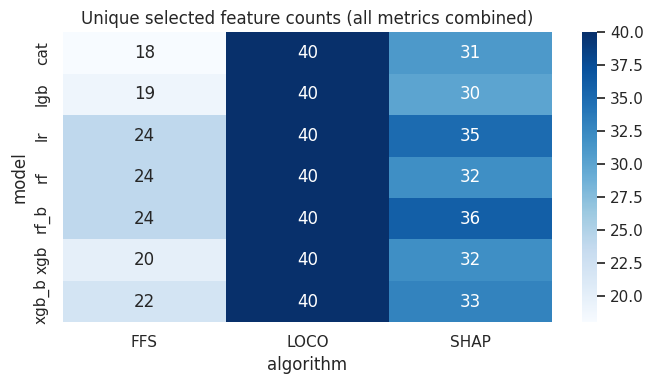

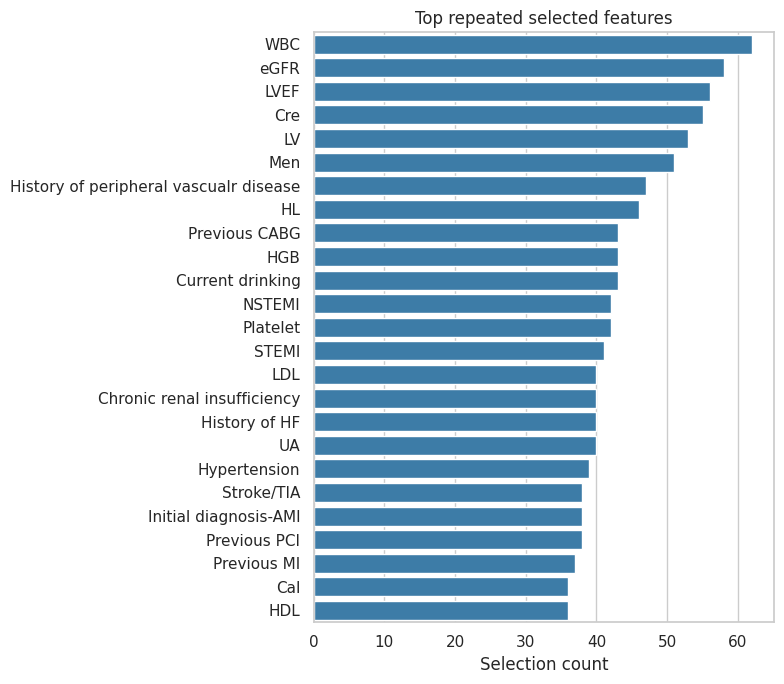

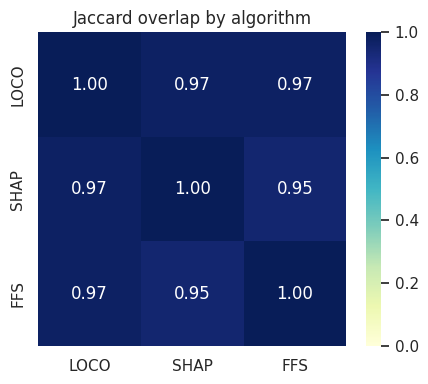

Saved outputs to /kaggle/working/model_feature_selectors
- selector_all_unique_features.csv
- selector_common_features_by_algorithm.csv
- selector_summary_long.csv
- selector_report.md
- selector_common_by_model_algorithms.csv
- selector_common_global_all_models_algorithms.csv
- selector_priority_feature_ranks.csv
- selector_union_by_model.csv
- selector_union_all_models_algorithms.csv


,feature
0,Age
1,CKD5
2,CaI
3,Chronic renal insufficiency
4,Cre


,algorithm,metric,n_common,features
0,LOCO,pr_auc,2,LV; eGFR
1,LOCO,f1,2,LV; eGFR
2,LOCO,f2,1,LV
3,SHAP,pr_auc,1,LV
4,SHAP,f1,1,eGFR
5,SHAP,f2,2,LV; WBC
6,FFS,pr_auc,1,Cre
7,FFS,f1,1,WBC
8,FFS,f2,1,WBC


,model,metric,n_common,features
0,cat,pr_auc,3,LV; WBC; eGFR
1,cat,f1,6,HGB; HL; LV; Platelet; WBC; eGFR
2,cat,f2,4,Hypertension; LV; WBC; eGFR
3,lgb,pr_auc,2,Cre; HL
4,lgb,f1,3,Current drinking; HL; WBC
5,lgb,f2,3,History of HF; Men; WBC
6,lr,pr_auc,4,Cre; Men; Min-stent diameter; TG
7,lr,f1,2,Cre; Men
8,lr,f2,5,Fast-Glu; LV; Men; WBC; eGFR
9,rf,pr_auc,3,LVEF; WBC; eGFR


,scope,n_common,features
0,all_models_all_algorithms,2,WBC; eGFR


,model,algorithm,metric,feature,rank,in_topk
0,cat,LOCO,pr_auc,"Age, years",NaN,False
1,cat,LOCO,pr_auc,Male sex,NaN,False
2,cat,LOCO,pr_auc,Current drinking,18.0,True
3,cat,LOCO,pr_auc,Diabetes mellitus,NaN,False
4,cat,LOCO,pr_auc,aspirin,NaN,False
5,cat,LOCO,pr_auc,Hypertension,20.0,True
6,cat,LOCO,pr_auc,Dapt,NaN,False
7,cat,LOCO,pr_auc,Dyslipidemia,NaN,False
8,cat,LOCO,pr_auc,HbA1C,NaN,False
9,cat,LOCO,pr_auc,Clopidogrel,NaN,False


,model,n_union_features,features
0,cat,30,CKD5; Chronic renal insufficiency; Cre; Curren...
1,lgb,30,CKD5; CaI; Cre; Current drinking; Current smok...
2,lr,33,Age; CKD5; CaI; Cre; Current drinking; Current...
3,rf,32,CKD5; CaI; Chronic renal insufficiency; Cre; C...
4,rf_b,33,CaI; Chronic renal insufficiency; Cre; Current...
5,xgb,32,CKD5; Chronic renal insufficiency; Cre; Curren...
6,xgb_b,30,CKD5; Chronic renal insufficiency; Cre; Curren...


,scope,n_union_features,features
0,all_models_all_algorithms_union,40,Age; CKD5; CaI; Chronic renal insufficiency; C...


In [10]:
# -------------------------------
# Final requested lists + report + compact plots
# -------------------------------

def topk_features(df, algorithm, model, metric, k=FEATURE_TOPK):
    sub = df[(df["algorithm"] == algorithm) & (df["model"] == model) & (df["metric"] == metric)]
    sub = sub.sort_values("rank").head(k)
    return set(sub["feature"].tolist())


all_unique = sorted(selector_summary_long["feature"].unique().tolist())
all_unique_df = pd.DataFrame({"feature": all_unique})
all_unique_df.to_csv(OUT_DIR / "selector_all_unique_features.csv", index=False)

models = sorted(selector_summary_long["model"].unique().tolist())
algorithms = ["LOCO", "SHAP", "FFS"]

rows = []
for algo in algorithms:
    for metric in SCORINGS:
        sets = [topk_features(selector_summary_long, algo, m, metric, FEATURE_TOPK) for m in models]
        common = sorted(set.intersection(*sets) if sets else set())
        rows.append({
            "algorithm": algo,
            "metric": metric,
            "n_common": len(common),
            "features": "; ".join(common),
        })

common_df = pd.DataFrame(rows)
common_df.to_csv(OUT_DIR / "selector_common_features_by_algorithm.csv", index=False)

required_cols = {"model", "algorithm", "metric", "rank", "feature"}
missing = required_cols - set(selector_summary_long.columns)
assert not missing, f"selector_summary_long missing required columns: {missing}"

# Optional across-metrics common per algorithm
rows2 = []
for algo in algorithms:
    sets = []
    for m in models:
        s = set()
        for metric in SCORINGS:
            s |= topk_features(selector_summary_long, algo, m, metric, FEATURE_TOPK)
        sets.append(s)
    common = sorted(set.intersection(*sets) if sets else set())
    rows2.append({"algorithm": algo, "scope": "across_metrics", "n_common": len(common), "features": "; ".join(common)})
common_across_df = pd.DataFrame(rows2)

# Common features across algorithms for each model, per metric
rows3 = []
for model in models:
    for metric in SCORINGS:
        sets = [
            topk_features(selector_summary_long, algo, model, metric, FEATURE_TOPK)
            for algo in algorithms
        ]
        common = sorted(set.intersection(*sets) if sets else set())
        rows3.append({
            "model": model,
            "metric": metric,
            "n_common": len(common),
            "features": "; ".join(common),
        })
common_by_model_algorithms_df = pd.DataFrame(rows3)
common_by_model_algorithms_df.to_csv(OUT_DIR / "selector_common_by_model_algorithms.csv", index=False)

# Global common features across all models and all algorithms (and all metrics)
global_sets = []
for model in models:
    for algo in algorithms:
        s = set()
        for metric in SCORINGS:
            s |= topk_features(selector_summary_long, algo, model, metric, FEATURE_TOPK)
        global_sets.append(s)
common_global_all = sorted(set.intersection(*global_sets) if global_sets else set())
global_common_df = pd.DataFrame({
    "scope": ["all_models_all_algorithms"],
    "n_common": [len(common_global_all)],
    "features": ["; ".join(common_global_all)],
})
global_common_df.to_csv(OUT_DIR / "selector_common_global_all_models_algorithms.csv", index=False)

# Requested: rank of priority features for each algorithm and each model
rank_rows = []
for model in models:
    for algo in algorithms:
        for metric in SCORINGS:
            sub = selector_summary_long[
                (selector_summary_long["model"] == model)
                & (selector_summary_long["algorithm"] == algo)
                & (selector_summary_long["metric"] == metric)
            ][["feature", "rank"]]
            rank_map = dict(zip(sub["feature"], sub["rank"]))
            for feature in PRIORITY_FEATURES:
                rank_rows.append({
                    "model": model,
                    "algorithm": algo,
                    "metric": metric,
                    "feature": feature,
                    "rank": rank_map.get(feature, np.nan),
                    "in_topk": feature in rank_map,
                })
priority_feature_ranks_df = pd.DataFrame(rank_rows)
priority_feature_ranks_df.to_csv(OUT_DIR / "selector_priority_feature_ranks.csv", index=False)

# Requested: union of features of all algorithms for each model
union_rows = []
for model in models:
    feat_union = set()
    for algo in algorithms:
        for metric in SCORINGS:
            feat_union |= topk_features(selector_summary_long, algo, model, metric, FEATURE_TOPK)
    union_rows.append({
        "model": model,
        "n_union_features": len(feat_union),
        "features": "; ".join(sorted(feat_union)),
    })
model_union_df = pd.DataFrame(union_rows)
model_union_df.to_csv(OUT_DIR / "selector_union_by_model.csv", index=False)

# Requested: union of all features of all models and algorithms
all_models_algorithms_union_df = pd.DataFrame({
    "scope": ["all_models_all_algorithms_union"],
    "n_union_features": [len(all_unique)],
    "features": ["; ".join(all_unique)],
})
all_models_algorithms_union_df.to_csv(OUT_DIR / "selector_union_all_models_algorithms.csv", index=False)

# Plot: model x algorithm counts (top-K records)
count_df = (
    selector_summary_long
    .groupby(["model", "algorithm"], as_index=False)["feature"]
    .nunique()
    .rename(columns={"feature": "n_unique_features"})
)
pivot_counts = count_df.pivot(index="model", columns="algorithm", values="n_unique_features").fillna(0)
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_counts, annot=True, fmt=".0f", cmap="Blues")
plt.title("Unique selected feature counts (all metrics combined)")
plt.tight_layout()
plt.savefig(OUT_DIR / "selector_model_algorithm_counts.png", dpi=150)
plt.show()

# Plot: top repeated features
feat_freq = (
    selector_summary_long
    .groupby("feature", as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .head(25)
)
plt.figure(figsize=(8, 7))
sns.barplot(data=feat_freq, y="feature", x="size", color="#2c7fb8")
plt.title("Top repeated selected features")
plt.xlabel("Selection count")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "selector_top_repeated_features.png", dpi=150)
plt.show()

# Minimal Jaccard overlap heatmap (algorithm-level, all model/metric top-k unions)
unions = {}
for algo in algorithms:
    s = set()
    for m in models:
        for metric in SCORINGS:
            s |= topk_features(selector_summary_long, algo, m, metric, FEATURE_TOPK)
    unions[algo] = s

jacc = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
for a in algorithms:
    for b in algorithms:
        u = unions[a] | unions[b]
        jacc.loc[a, b] = (len(unions[a] & unions[b]) / len(u)) if len(u) else 1.0

plt.figure(figsize=(4.5, 4))
sns.heatmap(jacc.astype(float), annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Jaccard overlap by algorithm")
plt.tight_layout()
plt.savefig(OUT_DIR / "selector_overlap_heatmap.png", dpi=150)
plt.show()

# Markdown report
report_lines = [
    "# Multi-Model Feature Selector Report",
    "",
    f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "## Split check (tabpfn protocol)",
    "",
    f"- n_total={split_manifest['n_total']}, n_train={split_manifest['n_train']}, n_test={split_manifest['n_test']}",
    f"- train_pos={split_manifest['train_pos']}, test_pos={split_manifest['test_pos']}",
    "",
    "## Models",
    "",
    f"- {', '.join(models)}",
    "",
    "## All unique selected features",
    "",
    f"- count={len(all_unique)}",
    "",
    "## Common features across all models per algorithm and metric",
    "",
]
for _, r in common_df.iterrows():
    report_lines.append(f"- {r['algorithm']} | {r['metric']} | n_common={int(r['n_common'])} | {r['features']}")

report_lines.extend(["", "## Common features across all models per algorithm (across metrics)", ""])
for _, r in common_across_df.iterrows():
    report_lines.append(f"- {r['algorithm']} | n_common={int(r['n_common'])} | {r['features']}")

report_lines.extend(["", "## Common features across algorithms for each model", ""])
for _, r in common_by_model_algorithms_df.iterrows():
    report_lines.append(
        f"- {r['model']} | {r['metric']} | LOCO∩SHAP∩FFS n_common={int(r['n_common'])} | {r['features']}"
    )

report_lines.extend(["", "## Global common features across all models and all algorithms", ""])
report_lines.append(
    f"- n_common={int(global_common_df['n_common'].iloc[0])} | {global_common_df['features'].iloc[0]}"
)

report_lines.extend(["", "## Priority feature ranks by model, algorithm, and metric", ""])
for model in models:
    report_lines.append("")
    report_lines.append(f"### {model}")
    model_rank_df = priority_feature_ranks_df[priority_feature_ranks_df["model"] == model]
    for algo in algorithms:
        report_lines.append(f"- **{algo}**")
        for metric in SCORINGS:
            sub = model_rank_df[(model_rank_df["algorithm"] == algo) & (model_rank_df["metric"] == metric)]
            rank_bits = []
            for _, row in sub.iterrows():
                rank_val = "NA" if pd.isna(row["rank"]) else int(row["rank"])
                rank_bits.append(f"{row['feature']}={rank_val}")
            report_lines.append(f"  - {metric}: " + ", ".join(rank_bits))

report_lines.extend(["", "## Union of features of all algorithms for each model", ""])
for _, r in model_union_df.iterrows():
    report_lines.append(
        f"- {r['model']} | n_union_features={int(r['n_union_features'])} | {r['features']}"
    )

report_lines.extend(["", "## Union of all features of all models and algorithms", ""])
report_lines.append(
    f"- n_union_features={int(all_models_algorithms_union_df['n_union_features'].iloc[0])} | {all_models_algorithms_union_df['features'].iloc[0]}"
)

(OUT_DIR / "selector_report.md").write_text("\n".join(report_lines), encoding="utf-8")

print("Saved outputs to", OUT_DIR)
print("- selector_all_unique_features.csv")
print("- selector_common_features_by_algorithm.csv")
print("- selector_summary_long.csv")
print("- selector_report.md")
print("- selector_common_by_model_algorithms.csv")
print("- selector_common_global_all_models_algorithms.csv")
print("- selector_priority_feature_ranks.csv")
print("- selector_union_by_model.csv")
print("- selector_union_all_models_algorithms.csv")

display(all_unique_df.head())
display(common_df)
display(common_by_model_algorithms_df)
display(global_common_df)
display(priority_feature_ranks_df.head(20))
display(model_union_df)
display(all_models_algorithms_union_df)

## Notes

- **Kaggle GPU:** In notebook settings, enable **GPU T4 x2** and Internet. Re-run the first config cell; you should see `GPU: True | Tesla T4`.
- GPU helps **CatBoost, XGBoost, LightGBM, TabPFN**. LR/RF stay CPU-only.
- `RUN_MODE="smoke"` is recommended first; then switch to `"full"`.
- `USE_CACHE=True` resumes from existing CSV outputs in `/kaggle/working/model_feature_selectors/`.
- If CatBoost GPU fails, the wrapper automatically retries on CPU.
- If `tabpfn` is unavailable (package/token), the notebook continues with the other models.